# BEoRN: 21-cm Signal by post-processing 21cmFAST density (LPT) and haloes (CHMF)

This notebook demonstrates how to use **BEoRN** to model the 21-cm brightness temperature signal from the Epoch of Reionization (EoR). BEoRN paints astrophysical radiation fields — X-ray heating, Lyman-alpha coupling, and ionization — onto a cosmological density field by placing pre-computed 1D profiles around dark matter halos.

The density fields and halo catalogs are generated here using [py21cmfast](https://github.com/21cmfast/21cmFAST), a semi-numerical simulation code for the EoR. BEoRN then uses these as input to produce full 3D maps of the 21-cm signal.

**Requirements:** Install BEoRN with the optional dependencies (py21cmfast and hmf):
```bash
pip install "git+https://github.com/cosmic-reionization/beorn.git[extra]"
```

**Output:** All results are saved under `./output/` and intermediate cached computations under `./cache/`. Both directories are created automatically.

In [1]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline

import logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

In [2]:
FILE_ROOT = Path(".")
CACHE_ROOT = FILE_ROOT / "cache"
OUTPUT_ROOT = FILE_ROOT / "output"

In [3]:
import beorn

import matplotlib as mpl
mpl.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'axes.titlesize': 14,
})


INFO:numexpr.utils:NumExpr defaulting to 10 threads.


## 1. Set simulation and astrophysical parameters

Here we define the cosmology, the simulation volume, and the astrophysical source model.

- **Simulation grid** (`simulation`): box size and grid resolution determine the spatial dynamic range.
- **Cosmo-sim inputs** (`cosmo_sim`): settings for the density-field source -- here `density_source='external'` (py21cmfast). `field_oversample` sets py21cmfast's internal resolution factor (its `DIM` grid, used for halo finding) relative to the output `Ncell` grid. `IC_seed` and the snapshot redshifts at which py21cmfast is run and BEoRN paints the signal are also here.
- **Solver** (`solver`): the high-resolution redshift grid over which the 1D RT profiles are integrated, and the halo mass and accretion-rate bins that define the profile lookup table. More profile redshift steps → more accurate bubble growth integration. The snapshot grid can be coarser — BEoRN matches each snapshot to the nearest profile redshift.
- **Cosmology** (`cosmology`): standard ΛCDM parameters. Must be consistent with the py21cmfast run.
- **Source model** (`source`): star formation efficiency, ionizing photon production, X-ray emission, and Lyman-alpha flux. These are the key parameters to vary when exploring different reionization histories.

> **Tip:** Start with a coarse grid (`Ncell=64`) for quick exploration, then increase resolution for production runs.

In [ ]:
parameters = beorn.structs.Parameters()

## Simulation grid
parameters.simulation.cores = 4
parameters.simulation.Lbox  = 100       # comoving Mpc/h
parameters.simulation.use_hunits = True # Lbox above is in Mpc/h, not physical Mpc
parameters.simulation.Ncell = 128

## Cosmo-sim inputs (py21cmfast-specific)
parameters.cosmo_sim.density_source = 'external'  # density field comes from py21cmfast, not native LPT
parameters.cosmo_sim.field_oversample = 3    # py21cmfast internal grid DIM = Ncell * field_oversample (HII_DIM stays Ncell)
parameters.cosmo_sim.IC_seed = 12345
parameters.cosmo_sim.snapshot_redshifts = np.arange(20, 5, -0.50)    # coarser snapshot grid

## Solver: profile redshift grid and halo mass/accretion bins
parameters.solver.redshifts                = np.arange(20, 5, -0.25) # fine profile grid
parameters.solver.halo_mass_bin_min        = 1e7
parameters.solver.halo_mass_bin_max        = 1e15
parameters.solver.halo_mass_nbin           = 40
parameters.solver.halo_mass_accretion_alpha = np.array([0.785, 0.795])

# Source age: how far back to integrate the emission history.
# z_source_start: no sources before this redshift (replaces hardcoded z=35).
# t_source_age: cap the lookback to this many Myr (None = use z_source_start only).
parameters.solver.z_source_start  = 35.0  # default
parameters.source.t_source_age    = None  # default (no age cap)

## Cosmology
parameters.cosmology.Om = 0.315
parameters.cosmology.Ob = 0.049
parameters.cosmology.Ol = 1-0.315
parameters.cosmology.h0  = 0.673

## Source parameters
# X-ray emission
parameters.source.energy_cutoff_min_xray = 500
parameters.source.energy_cutoff_max_xray = 10000
parameters.source.energy_min_sed_xray = 200
parameters.source.energy_max_sed_xray = 10000
parameters.source.alS_xray = 1.5
parameters.source.xray_normalisation = 0.3 * 3.4e40

# Lyman-alpha
parameters.source.n_lyman_alpha_photons = 9690
parameters.source.lyman_alpha_power_law = 0.0

# Ionization
parameters.source.Nion = 2000

# Escape fraction
parameters.source.f0_esc = 0.2
parameters.source.pl_esc = 0.5

# Star formation efficiency
parameters.source.f_st = 0.2
parameters.source.g1 = 0.49
parameters.source.g2 = -0.61
parameters.source.g3 = 4
parameters.source.g4 = -4
parameters.source.Mp = 1.6e11 * parameters.cosmology.h0
parameters.source.Mt = 1e9

# Minimum star-forming halo mass
parameters.source.halo_mass_min = 1e8

### Source model visualization

Before running anything, it is useful to inspect the astrophysical source model implied by the parameters above. The two key efficiency functions are:

- **Star-formation efficiency** $f_*(M_h)$: fraction of accreted baryons converted into stars (double power-law with a low-mass suppression below $M_t$).
- **Escape fraction** $f_\mathrm{esc}(M_h)$: fraction of ionising photons that escape into the IGM (power-law in halo mass).

These two functions, multiplied together and by $N_\mathrm{ion}$, set the ionising emissivity of each halo.

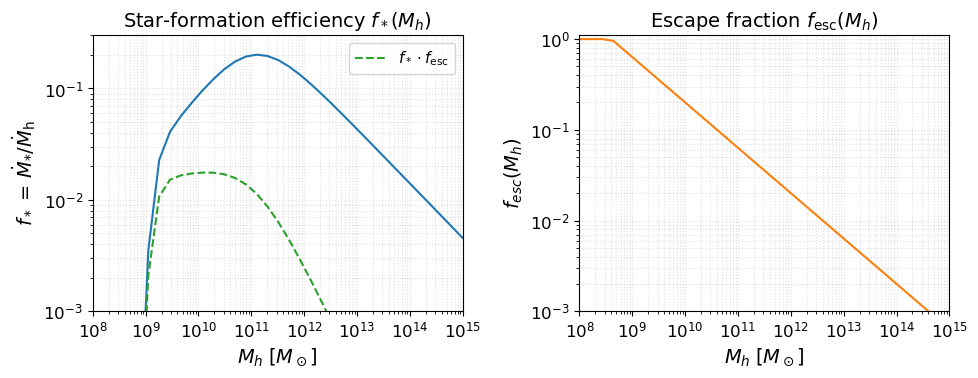

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

beorn.plotting.draw_star_formation_rate(axes[0], parameters, color='C0')
beorn.plotting.draw_f_esc(axes[1], parameters, color='C1')

# Overlay f_star * f_esc on the left panel to show the combined ionising efficiency
Mh_grid = parameters.solver.halo_mass_bins
keep = (Mh_grid > parameters.source.halo_mass_min) & (Mh_grid <= parameters.source.halo_mass_max)
Mh_plot = Mh_grid[keep]
from beorn.astro import f_star_Halo, f_esc as f_esc_func
combined = f_star_Halo(parameters, Mh_plot) * f_esc_func(parameters, Mh_plot)
axes[0].loglog(Mh_plot, combined, color='C2', ls='--', label=r'$f_* \cdot f_\mathrm{esc}$')
axes[0].legend(fontsize=11)

axes[0].set_title(r'Star-formation efficiency $f_*(M_h)$')
axes[1].set_title(r'Escape fraction $f_\mathrm{esc}(M_h)$')

for ax in axes:
    ax.set_xlabel(r'$M_h \; [M_\odot]$')
    ax.grid(True, which='both', ls=':', alpha=0.4)
    ax.set_xlim(1e8,1e15)
axes[0].set_ylim(1e-3,3e-1)
axes[1].set_ylim(1e-3,1.1)

plt.tight_layout()
plt.show()

## 2. Precompute radiation profiles

BEoRN pre-computes 1D radial profiles of X-ray heating, Lyman-alpha flux, and ionization around halos of different masses. These profiles capture how radiation from the first galaxies affects the surrounding IGM as a function of distance. Pre-computing them once and caching the result means they can be reused efficiently when painting different realisations or astrophysical models.

> **Note:** This step depends only on the astrophysical parameters above — it does not require the cosmological density field or halo catalogs generated in the next section.

In [6]:
cache_handler = beorn.io.Handler(CACHE_ROOT)

solver = beorn.precomputation.RadiationProfileSolver(
    parameters, parameters.cosmo_sim.snapshot_redshifts
)
profiles = solver.get_or_compute_profiles(cache_handler)

INFO:beorn.io.handler:Using persistence directory at cache
INFO:beorn.precomputation.solver:Loaded radiation profiles from cache (z=20.00→5.50, 30 steps).


### Inspecting the pre-computed 1D profiles

The figure below mirrors Figure 2 of [Schaeffer et al. 2023](https://arxiv.org/abs/2305.15466). Each panel corresponds to a different halo mass and shows how the radial profile evolves with redshift (blue → red):

1. **Halo mass accretion history** — exponential MAR model (grey) vs. Behroozi et al. 2020 simulations (gold).
2. **Lyman-α flux profile** $\rho_\alpha(r)$ — sets the WF coupling $x_\alpha$.
3. **Kinetic temperature profile** $T_k(r)$ — driven by X-ray heating.
4. **Ionization fraction** $x_\mathrm{HII}(r)$ — sharp bubble front expanding with time.

Adjust `mass_index` and the redshift/alpha lists to explore different halo masses or accretion histories.

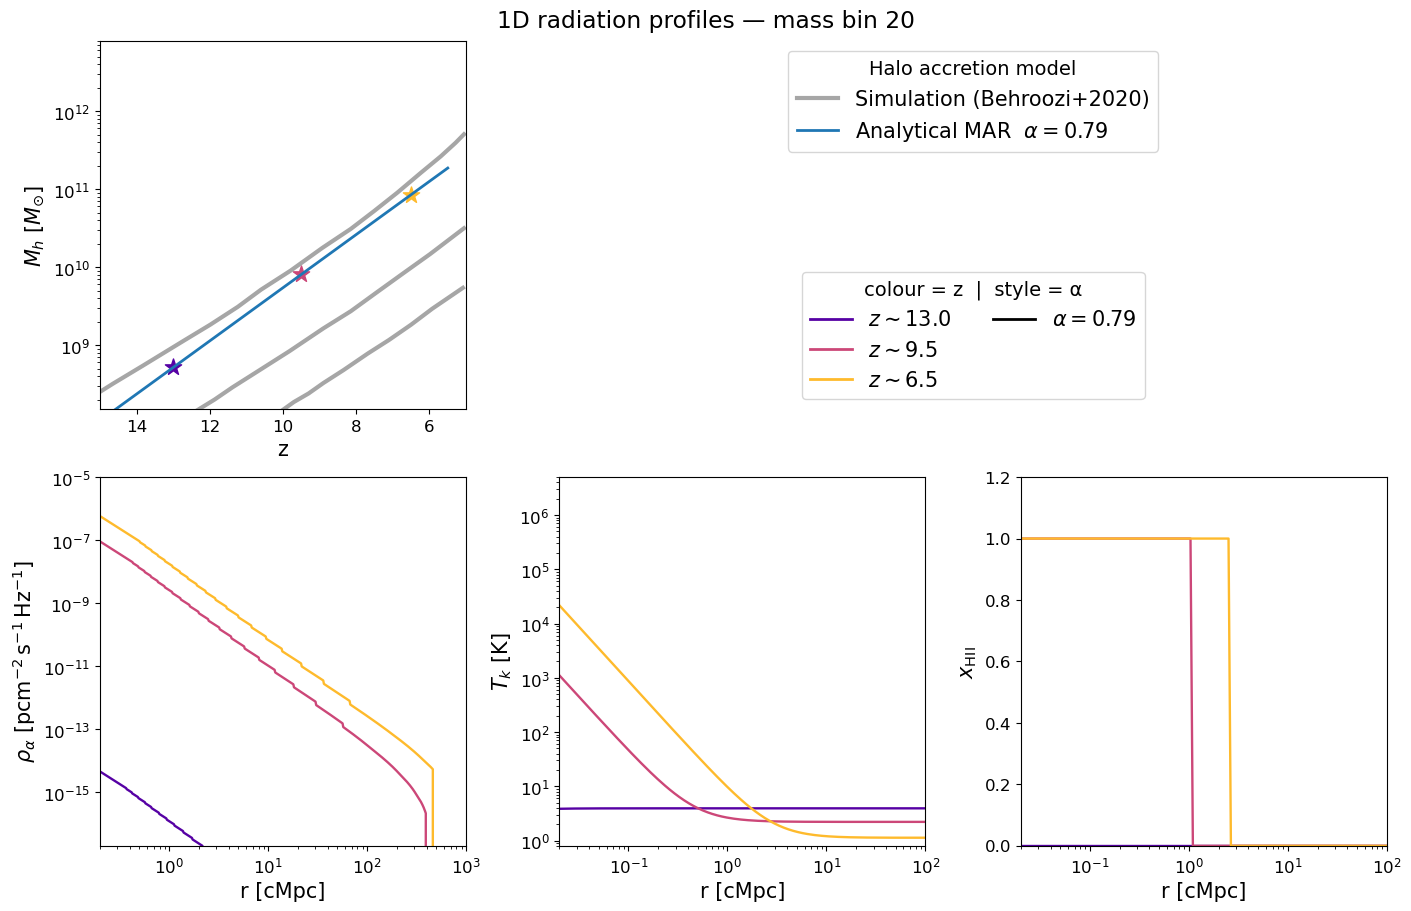

In [7]:
# Select a mid-range mass bin and three representative redshifts
# (matching roughly the three panels of Fig. 2 in arXiv:2305.15466)
mass_index = 20   # index into the 40-bin halo mass grid (~10^10–10^11 Msol depending on z)
profile_redshifts = [13.0, 9.5, 6.5]
# Use only the first alpha value to match the number of alpha bins in the cached profiles
profile_alphas = [parameters.solver.halo_mass_accretion_alpha[0]]

beorn.plotting.plot_1D_profiles(
    parameters,
    profiles,
    mass_index=mass_index,
    redshifts=profile_redshifts,
    alphas=profile_alphas,
    label=f"1D radiation profiles — mass bin {mass_index}",
    fontsize=15,
)

## 3. Generate the cosmological density field and halo catalogs

We use py21cmfast to produce the raw cosmological inputs: matter density fields and dark matter halo catalogs at each redshift. These encode where and how massive the first collapsed structures are — the seeds of the first galaxies.

This step only needs to run once for a given cosmology, box size, and random seed. If the data already exists from a previous run it will be reused automatically, so you can safely re-run this cell.

In [ ]:
loader = beorn.load_input_data.Py21cmFastLoader(parameters)
output_handler = beorn.io.Handler(OUTPUT_ROOT, input_tag=loader.input_tag)

loader.generate(output_handler)

## 4. Inspect the halo catalog and density field

Before running the full simulation, it is useful to check the input data. The halo mass function describes the abundance of dark matter halos as a function of mass and should match the analytical prediction (Sheth & Tormen 1999) for the given cosmology and redshift. We also show a 2D slice through the matter overdensity field, which reveals the large-scale cosmic web structure.

INFO:beorn.structs.halo_catalog:No alpha values provided, using default value of 0.79 for all halos.


Number of halos at z=7.0: 320931
Mass range: 1.78e+09 — 9.63e+11 Msol


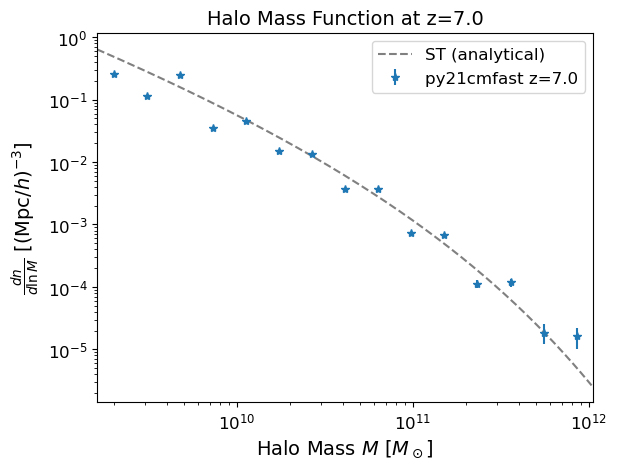

In [9]:
z_target = 7.0
z_index = np.argmin(np.abs(loader.redshifts - z_target))

halo_catalog = loader.load_halo_catalog(z_index)
print(f"Number of halos at z={z_target}: {len(halo_catalog.masses)}")
print(f"Mass range: {halo_catalog.masses.min():.2e} — {halo_catalog.masses.max():.2e} Msol")

# Plot halo mass function from the catalog with analytical Sheth & Tormen (1999) reference
fig, ax = plt.subplots()
beorn.plotting.plot_halo_mass_function(ax, halo_catalog, bin_count=15,
                                       label=f'py21cmfast z={z_target}',
                                       analytical_model='ST')
ax.set_title(f'Halo Mass Function at z={z_target}', fontsize=14)
ax.legend()
plt.show()

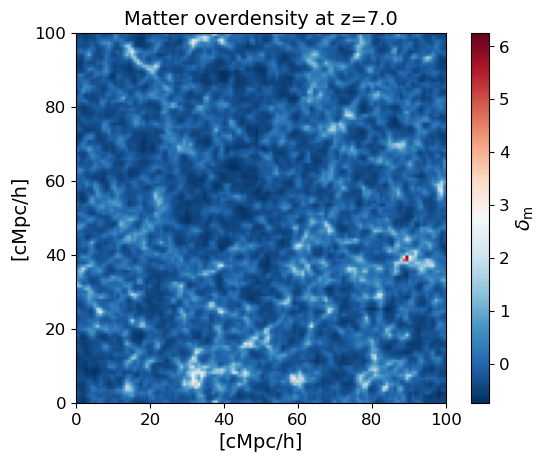

In [10]:
delta_m = loader.load_density_field(z_index)

Lbox = parameters.simulation.Lbox  # cMpc/h
extent = [0, Lbox, 0, Lbox]

plt.figure()
plt.imshow(delta_m[:, delta_m.shape[1] // 2, :], origin='lower', cmap='RdBu_r', extent=extent)
plt.colorbar(label=r'$\delta_\mathrm{m}$')
plt.xlabel('[cMpc/h]')
plt.ylabel('[cMpc/h]')
plt.title(f'Matter overdensity at z={z_target}')
plt.show()

## 5. Paint the 3D signal maps

BEoRN places the pre-computed profiles around each halo in the catalog and accumulates their contributions on the grid. This produces 3D maps of the ionization fraction, gas temperature, and Lyman-alpha coupling at each redshift — the ingredients needed to compute the 21-cm brightness temperature.

Snapshots that have already been computed are skipped automatically, so interrupted runs resume from where they left off.

In [11]:
p = beorn.painting.PaintingCoordinator(
    parameters,
    loader=loader,
    output_handler=output_handler,
)

# paint_full() returns immediately — grid fields are lazy.
# Each field (Grid_xHII, Grid_Temp, …) is backed by per-z HDF5 files;
# a slice is read from disk only when first accessed and then cached.
multi_z_quantities = p.paint_full(profiles)

INFO:beorn.painting.coordinator:============================================================
BEoRN model summary
  Cosmology   : Om=0.315, Ob=0.049, h0=0.673, sigma_8=0.83
  Grid        : Ncell=128, Lbox=100 Mpc/h
  Profile z   : z=20.0 -> 5.2 (60 steps)
  Snapshot z  : z=20.0 -> 5.5 (30 snapshots)
  1D RT bins  : 1.0e+07 - 1.0e+15 Msun at z=5.2 (40 bins, traced back via exp. accretion)
  Source      : f_st=0.2, Nion=2000, f0_esc=0.2
  X-ray       : norm=1.02e+40, E=[500, 10000] eV
  Lyman-alpha : n_phot=9690, star-forming above 1.0e+08 Msun
  Beorn hash  : cfdfd1e6
INFO:beorn.painting.coordinator:Painting profiles onto grid for 30 of 30 redshift snapshots. Using 4 processes on a single node.


Painting redshift snapshots:   0%|          | 0/30 [00:00<?, ?snapshot/s]

INFO:beorn.painting.coordinator:Found painted output for z=20.000 — skipping (set force_recompute=True to repaint).
INFO:beorn.painting.coordinator:Found painted output for z=19.500 — skipping (set force_recompute=True to repaint).
INFO:beorn.painting.coordinator:Found painted output for z=19.000 — skipping (set force_recompute=True to repaint).
INFO:beorn.painting.coordinator:Found painted output for z=18.500 — skipping (set force_recompute=True to repaint).
INFO:beorn.painting.coordinator:Found painted output for z=18.000 — skipping (set force_recompute=True to repaint).
INFO:beorn.painting.coordinator:Found painted output for z=17.500 — skipping (set force_recompute=True to repaint).
INFO:beorn.painting.coordinator:Found painted output for z=17.000 — skipping (set force_recompute=True to repaint).
INFO:beorn.painting.coordinator:Found painted output for z=16.500 — skipping (set force_recompute=True to repaint).
INFO:beorn.painting.coordinator:Found painted output for z=16.000 — skip

## 6. Visualise the 3D maps at a single redshift

We show a 2D slice through the simulation box for the three key fields at the chosen redshift: the ionization fraction $x_\mathrm{HII}$, the gas kinetic temperature $T_k$, and the 21-cm brightness temperature $\delta T_b$. The ionized bubbles visible in the $x_\mathrm{HII}$ map are driven by the same halos that appear in the mass function above.

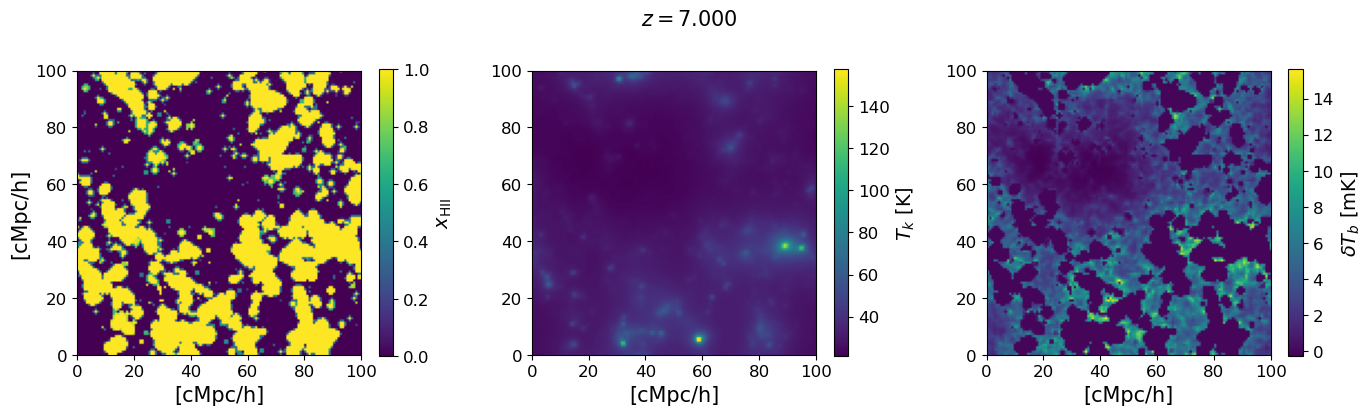

In [12]:
# Load only the single snapshot we want to visualise.
# snapshot() accepts a redshift value (nearest match) or an integer index,
# and opens only that one HDF5 file — minimal memory use.
snap = multi_z_quantities.snapshot(z_target)

xHII_grid = snap.Grid_xHII[:]  # 3D array: (Ncell, Ncell, Ncell)
dTb_grid  = snap.Grid_dTb      # derived from this snapshot only
Tk_grid   = snap.Grid_Temp[:]

mid = xHII_grid.shape[1] // 2
Lbox = parameters.simulation.Lbox  # cMpc/h
extent = [0, Lbox, 0, Lbox]

fig, axs = plt.subplots(1, 3, figsize=(14, 4))
for ax, grid, label in zip(axs,
                            [xHII_grid, Tk_grid, dTb_grid],
                            [r'$x_\mathrm{HII}$', r'$T_k$ [K]', r'$\delta T_b$ [mK]']):
    im = ax.imshow(grid[:, mid, :], origin='lower', cmap='viridis', extent=extent)
    ax.set_xlabel('[cMpc/h]', fontsize=15)
    fig.colorbar(im, ax=ax, label=label)
axs[0].set_ylabel('[cMpc/h]', fontsize=15)
fig.suptitle(f'$z={snap.z:.3f}$', fontsize=15)
plt.tight_layout()
plt.show()

## 7. Global history and power spectra

The global (volume-averaged) signal summarises the overall evolution of reionization. We show the redshift evolution of the mean brightness temperature, gas temperature, and ionization fraction, as well as the 21-cm power spectrum amplitude at a fixed wavenumber $k$. These are the primary observational targets of radio telescopes such as SKA, HERA, and MWA.

> **Memory note:** The `draw_*` plotting functions use `global_mean()` internally, which iterates snapshots one at a time so peak memory is one 3D grid. The power spectrum panel requires `Grid_dTb` across all $z$ and will load all base fields. For a memory-efficient global signal without the power spectrum, call each `draw_*` function individually.

Power spectrum:   0%|          | 0/30 [00:00<?, ?snapshot/s]

k=0.12 Mpc$^{-1}$


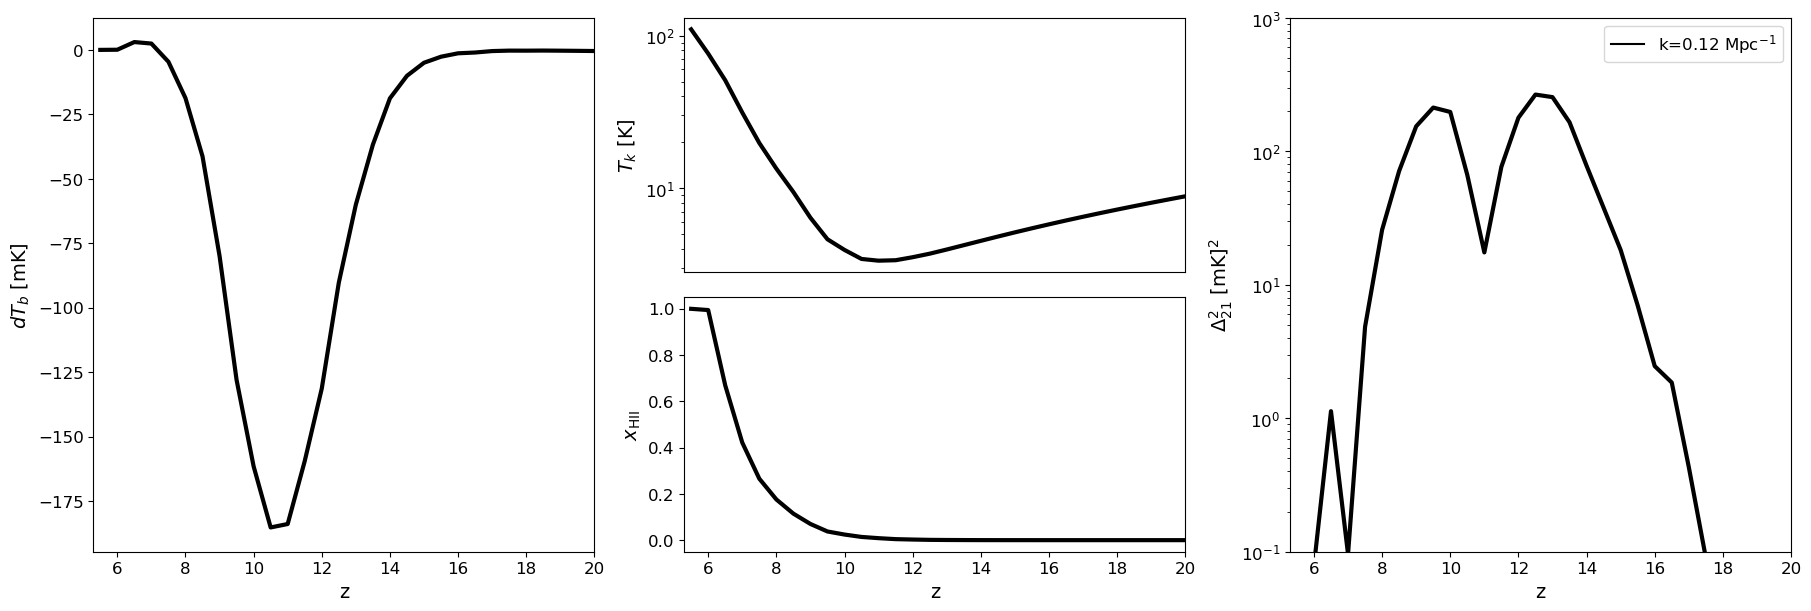

In [13]:
fig = plt.figure(constrained_layout=True, figsize=(18, 6))
gs = gridspec.GridSpec(2, 3, figure=fig)
ax1 = fig.add_subplot(gs[:, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 1], sharex=ax2)
ax4 = fig.add_subplot(gs[:, 2])

beorn.plotting.draw_dTb_signal(ax1, multi_z_quantities, color='k', lw=3)
beorn.plotting.draw_Temp_signal(ax2, multi_z_quantities, color='k', lw=3)
beorn.plotting.draw_xHII_signal(ax3, multi_z_quantities, color='k', lw=3)
kplot = beorn.plotting.draw_dTb_power_spectrum_of_z(
                    ax4, multi_z_quantities, parameters, k_value=0.1, color='k', lw=3)
ax4.plot([], [], color='k', label=f'k={kplot:.2f} Mpc$^{{-1}}$')
ax4.legend(loc=0)
ax2.axes.get_xaxis().set_visible(False)
plt.show()

### Saving and reusing statistics with `StatisticsEstimator`

`StatisticsEstimator` wraps a `TemporalCube` and computes the same quantities shown above (global means + dimensionless power spectrum), then writes them to an HDF5 file next to the cube directory.  On the next run the file is loaded automatically instead of recomputed.

The `draw_*` plotting functions accept a `StatisticsEstimator` directly — they read from the cached results instead of touching the large grid arrays.

You can add your own estimators by subclassing and appending to `_estimators`.  Here we add the spatial variance of $\delta T_b(z)$ as a simple example.

In [14]:
# --- Custom estimator: add spatial variance of dTb ---
class MyStats(beorn.structs.StatisticsEstimator):
    _estimators = beorn.structs.StatisticsEstimator._estimators + ['variance_signals']

    def variance_signals(self) -> dict:
        """Spatial variance of dTb at each redshift."""
        n_z = len(self.cube.z_snapshots)
        var_dTb = np.empty(n_z)
        for i in range(n_z):
            var_dTb[i] = np.var(self.cube.Grid_dTb[i])
        return {'var_dTb': var_dTb}

# Compute and save to  output/igm_stats_<tag>.h5  (auto-derived from cube path).
# On subsequent runs stats.results loads the file instead of recomputing.
stats = MyStats(multi_z_quantities, parameters)
saved_path = stats.save(path='output/igm_stats_test.h5')          # writes HDF5, caches results in stats._results
print(f"Statistics saved to: {saved_path}")

Power spectrum:   0%|          | 0/30 [00:00<?, ?snapshot/s]

Statistics saved to: output/igm_stats_test.h5


k=0.12 Mpc$^{-1}$


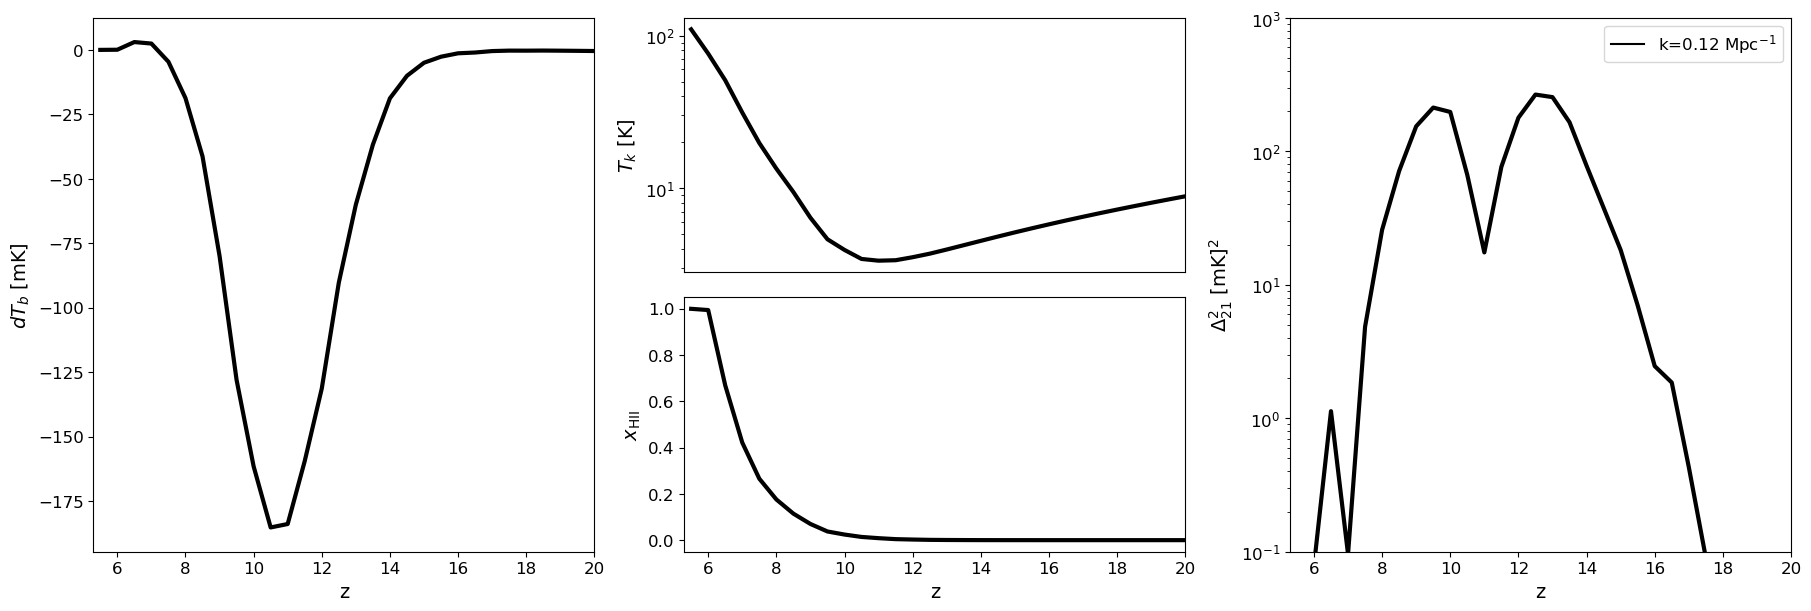

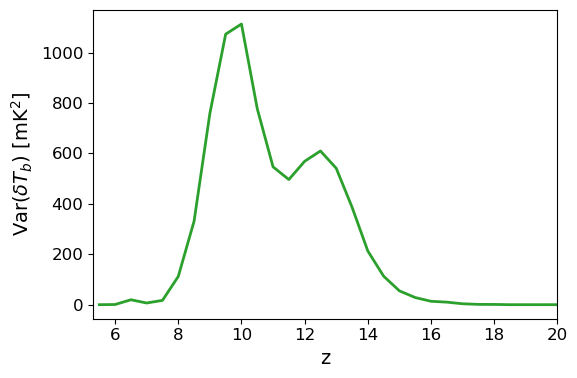

In [15]:
stats_loaded = beorn.structs.StatisticsEstimator.from_file(
    'output/igm_stats_test.h5'
)

# The draw_* functions accept the StatisticsEstimator directly
fig = plt.figure(constrained_layout=True, figsize=(18, 6))
gs = gridspec.GridSpec(2, 3, figure=fig)
ax1 = fig.add_subplot(gs[:, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 1], sharex=ax2)
ax4 = fig.add_subplot(gs[:, 2])

beorn.plotting.draw_dTb_signal(ax1, stats_loaded, color='k', lw=3)
beorn.plotting.draw_Temp_signal(ax2, stats_loaded, color='k', lw=3)
beorn.plotting.draw_xHII_signal(ax3, stats_loaded, color='k', lw=3)
kplot = beorn.plotting.draw_dTb_power_spectrum_of_z(ax4, stats_loaded, k_value=0.1, color='k', lw=3)
ax4.plot([], [], color='k', label=f'k={kplot:.2f} Mpc$^{{-1}}$')
ax4.legend(loc=0)
ax2.axes.get_xaxis().set_visible(False)

# Also show the variance as an extra panel
fig2, ax_var = plt.subplots(figsize=(6, 4))
r = stats.results
ax_var.plot(r['z'], r['var_dTb'], color='C2', lw=2)
ax_var.set_xlabel('z')
ax_var.set_ylabel(r'$\mathrm{Var}(\delta T_b)$ [mK$^2$]')
ax_var.set_xlim(r['z'].min() - 0.2, r['z'].max())
plt.tight_layout()
plt.show()

## 8. Lightcone

A lightcone stitches together slices from different redshifts to mimic an actual observation: as we observe further into the past, the signal evolves. This is what a radio telescope effectively measures along the line of sight. The horizontal axis shows increasing redshift (earlier cosmic times) from right to left.

Making lightcone between 0.047619 < z < 0.153845


100%|██████████| 559/559 [00:00<00:00, 4530.13it/s]


...done


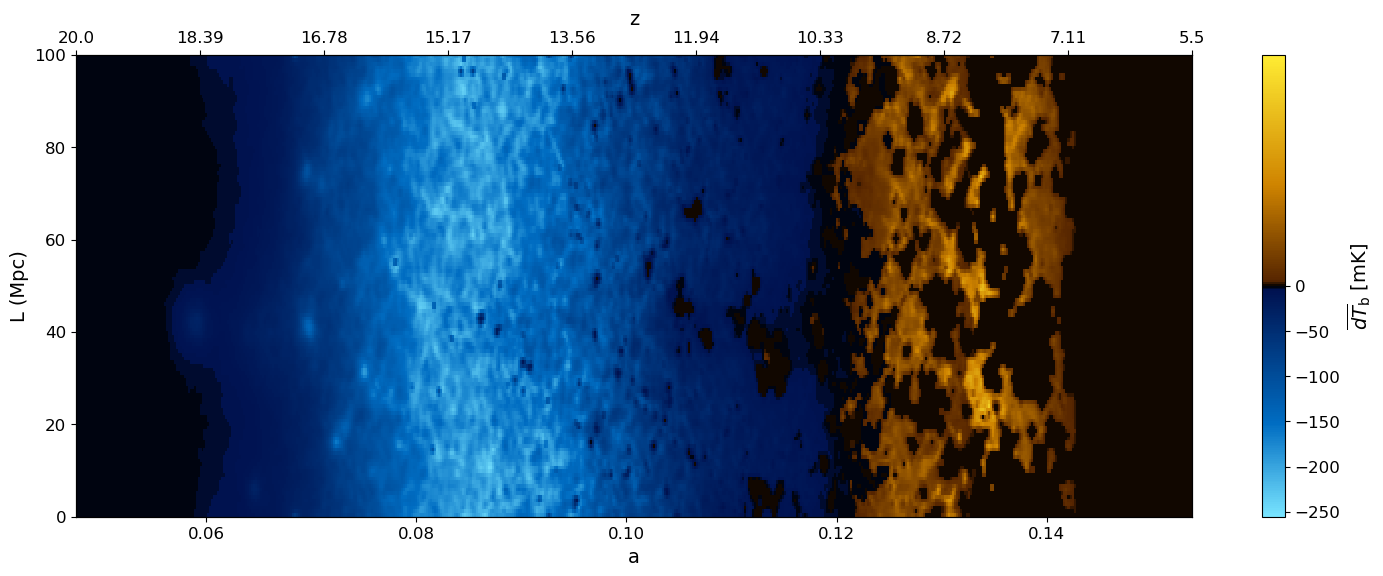

In [16]:
lightcone = beorn.structs.Lightcone.build(
    parameters,
    multi_z_quantities,
    quantity="Grid_dTb",
)

fig, ax = plt.subplots(figsize=(18, 6))
beorn.plotting.plot_lightcone(lightcone, ax, "", slice_number=30)
fig.show()

## 9. Compare two runs

To compare different astrophysical models side-by-side, point `IGM_DATA_1` and `IGM_DATA_2` at two `igm_data_*` output directories. BEoRN reads the parameters and grid data directly from those folders — no need to re-specify any parameters manually.

Each `TemporalCube.read()` call recovers the full `Parameters` object from the embedded HDF5 metadata, so `param1` and `param2` automatically reflect the settings used to produce each run.

In [17]:
# Edit these two paths to point at your igm_data_* output directories
IGM_DATA_1 = Path("output/igm_data_py21cmfast_N128_D384_L100_seed12345_4660308f_4024dbb5")
IGM_DATA_2 = Path("output/igm_data_py21cmfast_N128_D384_L100_seed12345_4660308f_457d9d8c")

multi_z_quantities_1 = beorn.structs.TemporalCube.read(IGM_DATA_1)
multi_z_quantities_2 = beorn.structs.TemporalCube.read(IGM_DATA_2)

param1 = multi_z_quantities_1.parameters
param2 = multi_z_quantities_2.parameters

INFO:beorn.structs.temporal_cube:Opened 30 snapshots from output/igm_data_py21cmfast_N128_D384_L100_seed12345_4660308f_4024dbb5 (grid data is lazy — slices load on demand).
INFO:beorn.structs.temporal_cube:Opened 30 snapshots from output/igm_data_py21cmfast_N128_D384_L100_seed12345_4660308f_457d9d8c (grid data is lazy — slices load on demand).


Power spectrum:   0%|          | 0/30 [00:00<?, ?snapshot/s]

k=0.12 Mpc$^{-1}$


Power spectrum:   0%|          | 0/30 [00:00<?, ?snapshot/s]

k=0.12 Mpc$^{-1}$


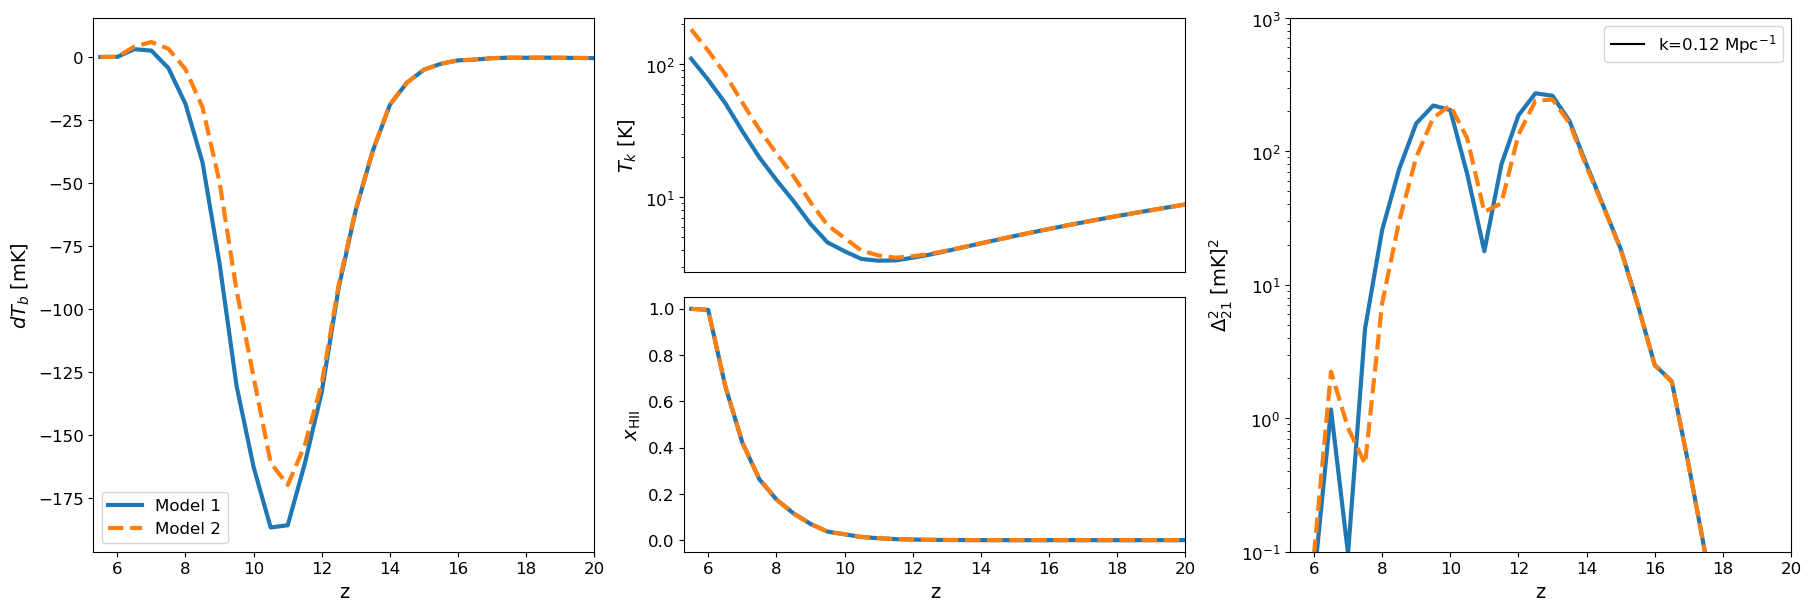

In [18]:
label1 = "Model 1"
label2 = "Model 2"

fig = plt.figure(constrained_layout=True, figsize=(18, 6))
gs = gridspec.GridSpec(2, 3, figure=fig)
ax1 = fig.add_subplot(gs[:, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 1], sharex=ax2)
ax4 = fig.add_subplot(gs[:, 2])

for grid, params, label, color, lstyle in [
    (multi_z_quantities_1, param1, label1, 'C0', '-'),
    (multi_z_quantities_2, param2, label2, 'C1', '--'),
]:
    beorn.plotting.draw_dTb_signal(ax1, grid, label=label, color=color, ls=lstyle, lw=3)
    beorn.plotting.draw_Temp_signal(ax2, grid, label=label, color=color, ls=lstyle, lw=3)
    beorn.plotting.draw_xHII_signal(ax3, grid, label=label, color=color, ls=lstyle, lw=3)
    kplot = beorn.plotting.draw_dTb_power_spectrum_of_z(
                    ax4, grid, params, label=None, k_value=0.1, color=color, ls=lstyle, lw=3)

ax1.legend()
ax4.plot([], [], color='k', label=f'k={kplot:.2f} Mpc$^{{-1}}$')
ax4.legend(loc=0)
ax2.axes.get_xaxis().set_visible(False)
plt.show()